# INSTALL/Import Libraries

In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load Dataset

In [53]:
import os
import pandas as pd

DATASET_PATH = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

metadata_path = os.path.join(DATASET_PATH, "HAM10000_metadata.csv")
df = pd.read_csv(metadata_path)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


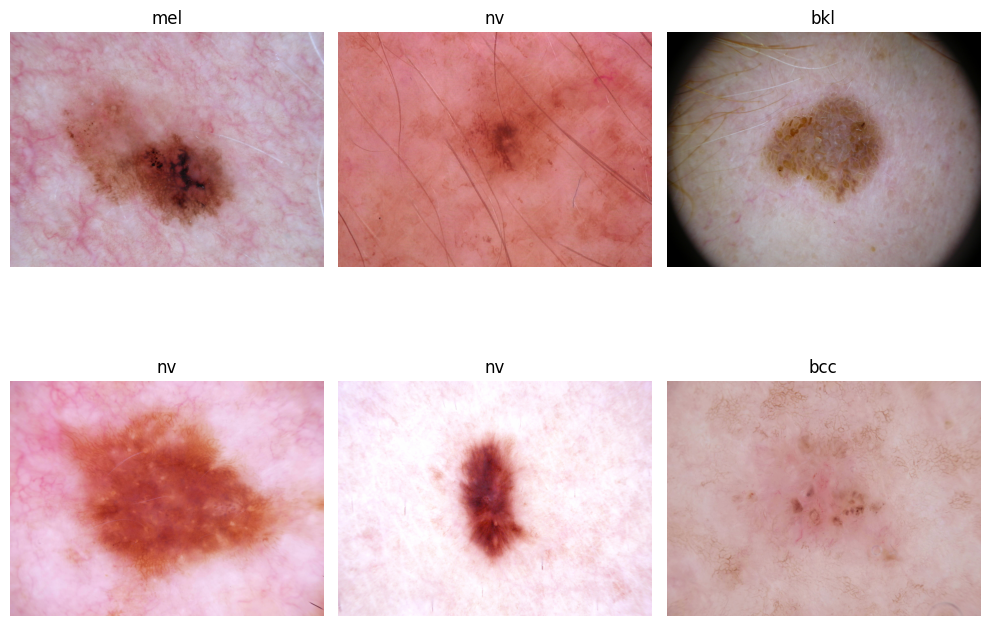

In [79]:
import cv2

fig, axes = plt.subplots(2,3, figsize=(10,8))

for ax, (_, row) in zip(axes.flatten(), df.sample(6).iterrows()):
    img = cv2.imread(row["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(row["dx"])
    ax.axis("off")

plt.tight_layout()
plt.show()

# ADD Image Path

In [54]:
image_dir_1 = os.path.join(DATASET_PATH, "HAM10000_images_part_1")
image_dir_2 = os.path.join(DATASET_PATH, "HAM10000_images_part_2")

def get_image_path(image_id):
    path1 = os.path.join(image_dir_1, image_id + ".jpg")
    path2 = os.path.join(image_dir_2, image_id + ".jpg")
    
    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None

df["image_path"] = df["image_id"].apply(get_image_path)

print("Missing image paths:", df["image_path"].isnull().sum())
df[["image_id", "dx", "age", "sex", "localization", "image_path"]].head()

Missing image paths: 0


,image_id,dx,age,sex,localization,image_path
0,ISIC_0027419,bkl,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,ISIC_0025030,bkl,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,ISIC_0026769,bkl,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,ISIC_0025661,bkl,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,ISIC_0031633,bkl,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnis...


# Basic Dataset Information

Total images: 10015

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


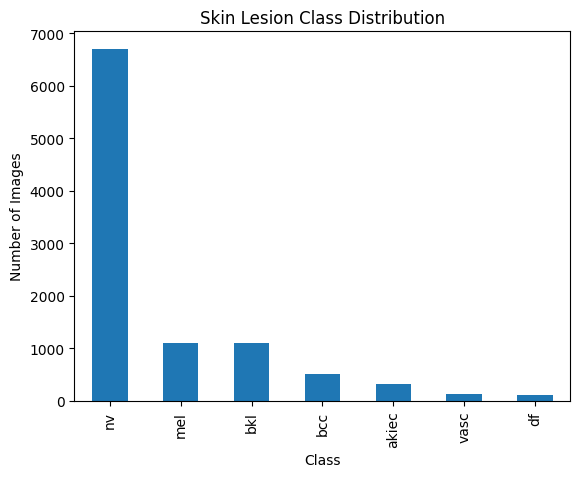

In [55]:
print("Total images:", len(df))
print("\nClass distribution:")
print(df["dx"].value_counts())

df["dx"].value_counts().plot(kind="bar")
plt.title("Skin Lesion Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# Metadata Pre-Processing

In [56]:
df["age"] = df["age"].fillna(df["age"].median())
df["sex"] = df["sex"].fillna("unknown")
df["localization"] = df["localization"].fillna("unknown")

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["dx"])

num_classes = len(label_encoder.classes_)

print("Classes:", label_encoder.classes_)
print("Number of classes:", num_classes)

Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
Number of classes: 7


# Enccode Metadata

In [57]:
metadata_df = pd.get_dummies(df[["sex", "localization"]], drop_first=False)

metadata_df["age"] = df["age"]

scaler = StandardScaler()
metadata_df["age"] = scaler.fit_transform(metadata_df[["age"]])

metadata_features = metadata_df.values.astype("float32")

print("Metadata shape:", metadata_features.shape)

Metadata shape: (10015, 19)


# Train-Test Split

In [58]:
train_df, test_df, train_meta, test_meta = train_test_split(
    df,
    metadata_features,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

train_df, val_df, train_meta, val_meta = train_test_split(
    train_df,
    train_meta,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 6409
Validation: 1603
Test: 2003


# Image Loading Function

In [59]:
IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    return image, label

# Create Image Only Dataset

In [60]:
def create_image_dataset(dataframe, batch_size=32, shuffle=True):
    paths = dataframe["image_path"].values
    labels = dataframe["label"].values
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        dataset = dataset.shuffle(1000)
        
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = create_image_dataset(train_df, BATCH_SIZE, shuffle=True)
val_ds = create_image_dataset(val_df, BATCH_SIZE, shuffle=False)
test_ds = create_image_dataset(test_df, BATCH_SIZE, shuffle=False)

# Create Metadata Fusion Dataset

In [61]:
def load_image_with_metadata(path, metadata, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    
    return {"image_input": image, "metadata_input": metadata}, label

def create_fusion_dataset(dataframe, metadata, batch_size=32, shuffle=True):
    paths = dataframe["image_path"].values
    labels = dataframe["label"].values
    
    dataset = tf.data.Dataset.from_tensor_slices((paths, metadata, labels))
    dataset = dataset.map(load_image_with_metadata, num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        dataset = dataset.shuffle(1000)
        
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_fusion_ds = create_fusion_dataset(train_df, train_meta, BATCH_SIZE, shuffle=True)
val_fusion_ds = create_fusion_dataset(val_df, val_meta, BATCH_SIZE, shuffle=False)
test_fusion_ds = create_fusion_dataset(test_df, test_meta, BATCH_SIZE, shuffle=False)

# Class Weight for Imbalanced Dataset

In [62]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(4.380724538619275),
 1: np.float64(2.782891880156318),
 2: np.float64(1.3023775655354604),
 3: np.float64(12.372586872586872),
 4: np.float64(1.2859149277688604),
 5: np.float64(0.2133701767819689),
 6: np.float64(10.061224489795919)}

# Data Augmentation

In [63]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Model 1: CUSTOM CNN

In [64]:
def build_custom_cnn():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
data_augmentation,
        
        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D(),
        
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D(),
        
        layers.Conv2D(128, (3,3), activation="relu"),
        layers.MaxPooling2D(),
        
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

cnn_model = build_custom_cnn()
cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,663 (432.28 KB)

 Trainable params: 110,663 (432.28 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 95ms/step - accuracy: 0.3085 - loss: 1.8529 - val_accuracy: 0.2371 - val_loss: 1.9585
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.3704 - loss: 1.7524 - val_accuracy: 0.2926 - val_loss: 1.7313
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 23s 100ms/step - accuracy: 0.3895 - loss: 1.6700 - val_accuracy: 0.4629 - val_loss: 1.2643
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.4302 - loss: 1.5626 - val_accuracy: 0.4248 - val_loss: 1.6586
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.4509 - loss: 1.4981 - val_accuracy: 0.3699 - val_loss: 1.7109
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.4587 - loss: 1.4471 - val_accuracy: 0.5134 - val_loss: 1.1601
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.4750 - loss: 1.4076 - val_accuracy: 0.4304 - val_loss: 1.5386
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.4740 - loss: 1.3713 -

# Model 2: MobileNetV2 Image Only

In [66]:
def build_mobilenet_image_only():

    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    # Fine-tuning
    base_model.trainable = True

    for layer in base_model.layers[:-20]:
        layer.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = base_model(inputs, training=True)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)

    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


mobilenet_model = build_mobilenet_image_only()

mobilenet_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 1,370,951 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

# Model 3: MobileNetV2 + Metadata Fusion

In [67]:
def build_metadata_fusion_model(metadata_dim):

    image_input = layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3),
        name="image_input"
    )

    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    # Fine-tuning
    base_model.trainable = True

    for layer in base_model.layers[:-20]:
        layer.trainable = False

    x1 = base_model(image_input, training=True)
    x1 = layers.GlobalAveragePooling2D()(x1)
    x1 = layers.Dense(128, activation="relu")(x1)

    metadata_input = layers.Input(
        shape=(metadata_dim,),
        name="metadata_input"
    )

    x2 = layers.Dense(64, activation="relu")(metadata_input)
    x2 = layers.Dense(32, activation="relu")(x2)

    combined = layers.Concatenate()([x1, x2])
    combined = layers.Dense(128, activation="relu")(combined)
    combined = layers.Dropout(0.4)(combined)

    output = layers.Dense(
        num_classes,
        activation="softmax"
    )(combined)

    model = models.Model(
        inputs=[image_input, metadata_input],
        outputs=output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


metadata_dim = train_meta.shape[1]

fusion_model = build_metadata_fusion_model(metadata_dim)

fusion_model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_input      │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 64)        │      1,280 │ metadata_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 32)        │      2,080 │ dense_30[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 160)       │          0 │ dense_29[0][0],   │
│ (Concatenate)       │                   │            │ dense_31[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 128)       │     20,608 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ dense_32[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 7)         │        903 │ dropout_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,446,823 (9.33 MB)

 Trainable params: 1,394,919 (5.32 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

# Evaluation Function

In [68]:
def evaluate_image_model(model, dataset, dataframe, model_name):
    y_true = dataframe["label"].values
    y_pred_prob = model.predict(dataset)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    
    print(f"\n{model_name} Results")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    ))
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }, y_pred


def evaluate_fusion_model(model, dataset, dataframe, model_name):
    y_true = dataframe["label"].values
    y_pred_prob = model.predict(dataset)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    
    print(f"\n{model_name} Results")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    ))
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }, y_pred

# Run Evaluation

In [69]:
history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 50s 161ms/step - accuracy: 0.4462 - loss: 1.5024 - val_accuracy: 0.7255 - val_loss: 0.8234
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.6132 - loss: 0.9058 - val_accuracy: 0.7124 - val_loss: 0.8099
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.6847 - loss: 0.6541 - val_accuracy: 0.7449 - val_loss: 0.7617
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.7499 - loss: 0.4982 - val_accuracy: 0.7187 - val_loss: 0.8080
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.7884 - loss: 0.3798 - val_accuracy: 0.6656 - val_loss: 1.0908
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.8203 - loss: 0.2960 - val_accuracy: 0.7118 - val_loss: 0.9247
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.8536 - loss: 0.2361 - val_accuracy: 0.7080 - val_loss: 1.0386
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.8822 - loss: 0.1716 -

In [70]:
history_fusion = fusion_model.fit(
    train_fusion_ds,
    validation_data=val_fusion_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 51s 166ms/step - accuracy: 0.4026 - loss: 1.5630 - val_accuracy: 0.7012 - val_loss: 0.9177
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.5884 - loss: 0.9817 - val_accuracy: 0.7430 - val_loss: 0.7404
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.6666 - loss: 0.7379 - val_accuracy: 0.7105 - val_loss: 0.7868
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.7227 - loss: 0.5420 - val_accuracy: 0.6800 - val_loss: 0.8340
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.7817 - loss: 0.3979 - val_accuracy: 0.6556 - val_loss: 0.9313
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.8252 - loss: 0.2796 - val_accuracy: 0.6463 - val_loss: 0.9961
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.8593 - loss: 0.2072 - val_accuracy: 0.6762 - val_loss: 0.9716
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - accuracy: 0.8794 - loss: 0.1779 -

In [71]:
cnn_result, cnn_pred = evaluate_image_model(
    cnn_model,
    test_ds,
    test_df,
    "Custom CNN"
)

mobilenet_result, mobilenet_pred = evaluate_image_model(
    mobilenet_model,
    test_ds,
    test_df,
    "MobileNetV2 Image Only"
)

fusion_result, fusion_pred = evaluate_fusion_model(
    fusion_model,
    test_fusion_ds,
    test_df,
    "MobileNetV2 + Metadata Fusion"
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step

Custom CNN Results
Accuracy: 0.5097353969046431
Precision: 0.7177734053142182
Recall: 0.5097353969046431
F1-score: 0.5619336002191989

Classification Report:
              precision    recall  f1-score   support

       akiec       0.21      0.38      0.27        65
         bcc       0.24      0.17      0.20       103
         bkl       0.31      0.36      0.33       220
          df       0.06      0.30      0.09        23
         mel       0.26      0.67      0.37       223
          nv       0.94      0.54      0.69      1341
        vasc       0.27      0.82      0.41        28

    accuracy                           0.51      2003
   macro avg       0.33      0.46      0.34      2003
weighted avg       0.72      0.51      0.56      2003

63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 149ms/step

MobileNetV2 Image Only Results
Accuracy: 0.6794807788317524
Precision: 0.7972780704794143
Recall: 0.6794807788317524
F1-score: 0.697861726098975

Classification 

In [78]:
results_df = pd.DataFrame([
    cnn_result,
    mobilenet_result,
    fusion_result
])

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Custom CNN,0.509735,0.717773,0.509735,0.561934
1,MobileNetV2 Image Only,0.679481,0.797278,0.679481,0.697862
2,MobileNetV2 + Metadata Fusion,0.721917,0.800912,0.721917,0.744546


In [ ]:
plot_training_history(history_cnn, "Custom CNN Accuracy")
plot_training_history(history_mobilenet, "MobileNetV2 Accuracy")
plot_training_history(history_fusion, "MobileNetV2 + Metadata Fusion Accuracy")

# Comparison Table

In [72]:
results_df = pd.DataFrame([
    cnn_result,
    mobilenet_result,
    fusion_result
])

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Custom CNN,0.509735,0.717773,0.509735,0.561934
1,MobileNetV2 Image Only,0.679481,0.797278,0.679481,0.697862
2,MobileNetV2 + Metadata Fusion,0.721917,0.800912,0.721917,0.744546


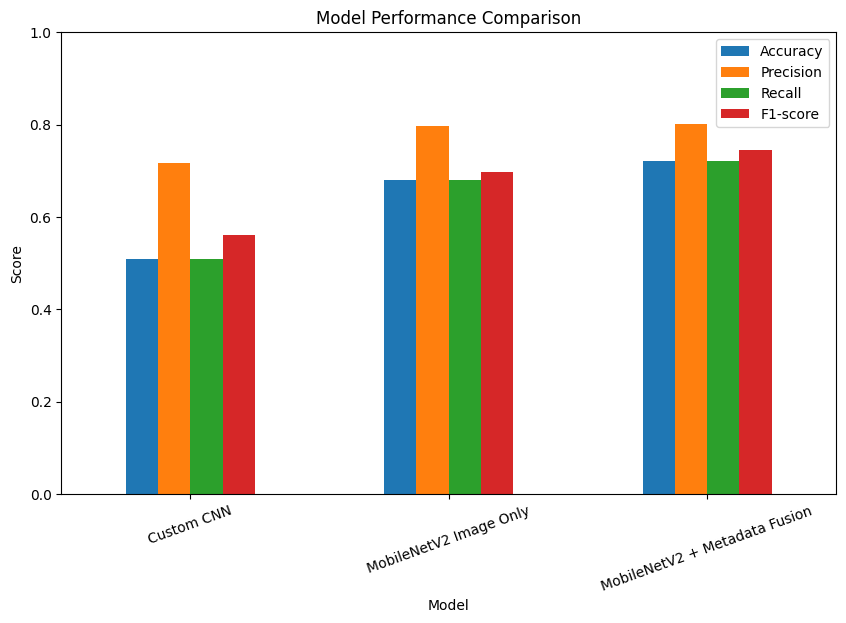

In [73]:
results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1-score"],
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

# Confusion Matrix for Best Model

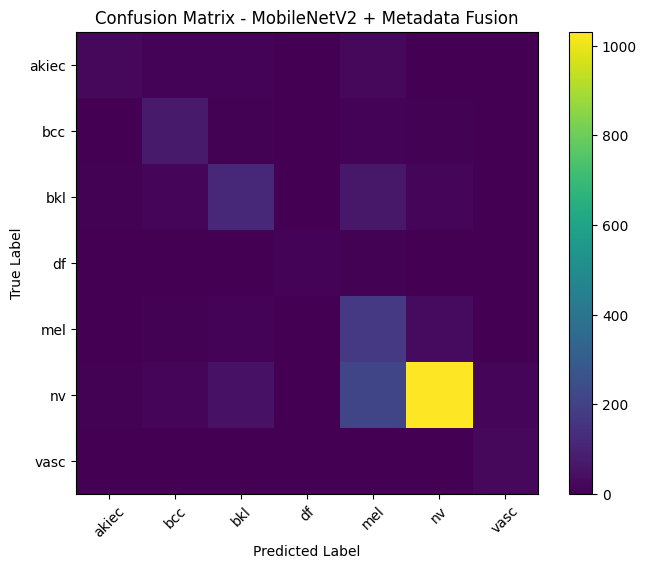

In [74]:
best_pred = fusion_pred

cm = confusion_matrix(test_df["label"].values, best_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix - MobileNetV2 + Metadata Fusion")
plt.colorbar()
plt.xticks(np.arange(num_classes), label_encoder.classes_, rotation=45)
plt.yticks(np.arange(num_classes), label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [75]:
mobilenet_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,164,759 (19.70 MB)

 Trainable params: 1,370,951 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 2,741,904 (10.46 MB)

# Training Graph

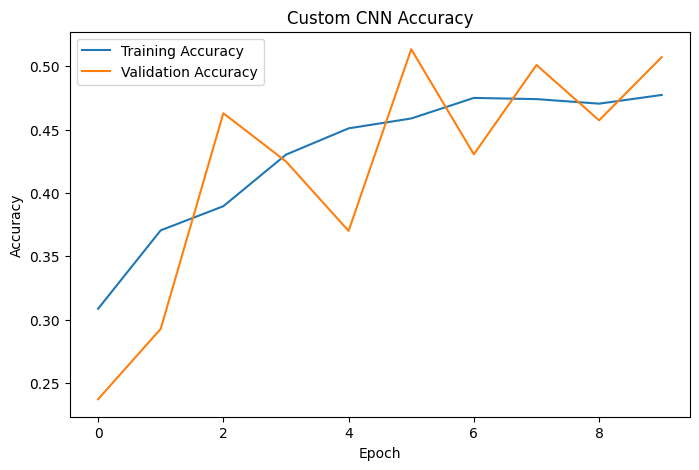

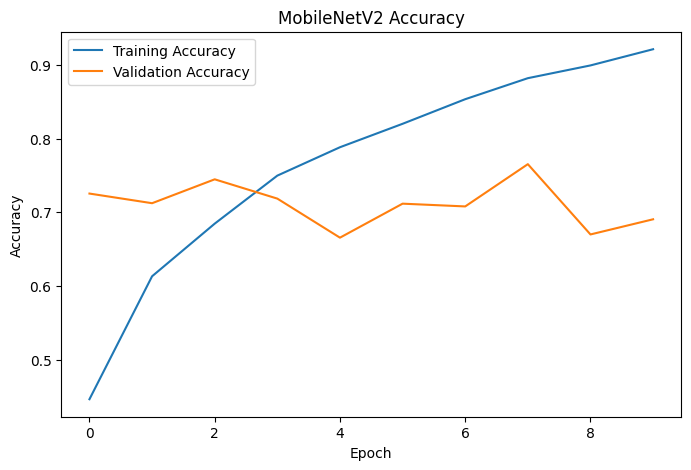

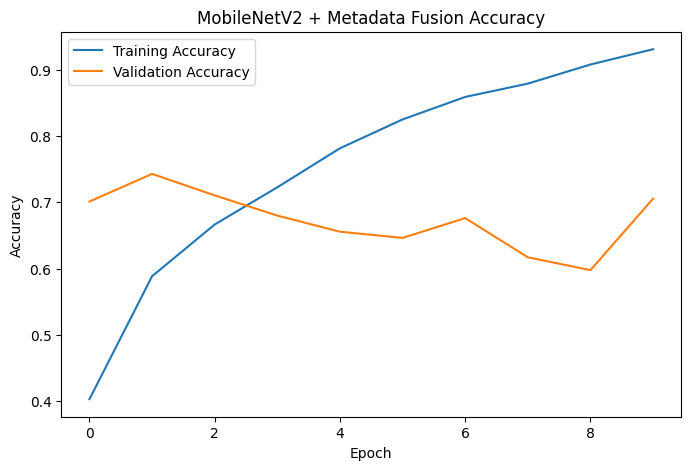

In [76]:
def plot_training_history(history, title):
    plt.figure(figsize=(8,5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_training_history(history_cnn, "Custom CNN Accuracy")
plot_training_history(history_mobilenet, "MobileNetV2 Accuracy")
plot_training_history(history_fusion, "MobileNetV2 + Metadata Fusion Accuracy")

# Save Best Model

In [77]:
fusion_model.save("SkinGuard_XAI_Metadata_Fusion_Model.h5")
print("Model saved successfully.")

Model saved successfully.
